# PRONTO phase 1: single heat source, equity by building type

MILP that designs a district heating network fed by **one known heat source** (PuLP + CBC). It chooses which pipes to build and how much heat flows through each pipe, at minimum net cost, under tree-structure, heat-balance, pipe-capacity and source-capacity constraints. See the repository README for the full mathematical model.

## Equity constraint used in this notebook: Equity by building type

Each building type $t$ (housing, public services, businesses) must make up at least a share $\mu_t$ of the connected pipes:

$$\forall t,\quad \sum_{i \neq j} N_{jt} X_{ij} \;\ge\; \mu_t \sum_{i \neq j} X_{ij}$$

**Input:** `data/phase1_input_known_source.xlsx`

In [ ]:
# Input file: data/phase1_input_known_source.xlsx
# On Google Colab, upload the file when asked; locally it is read from the data/ folder.
try:
    from google.colab import files
    uploaded = files.upload()
    INPUT_FILE = next(iter(uploaded))
except ImportError:
    INPUT_FILE = "../../data/phase1_input_known_source.xlsx"


In [6]:
from pulp import *
import pandas as pd
import numpy as np
from itertools import combinations
import math as mt

if __name__ == "__main__":

    InputData = "InputDataExample.xlsx"
    # Input Data Preparation
    def read_excel_data(filename, sheet_name):
        data = pd.read_excel(filename, sheet_name=sheet_name, header=None)
        values = data.values
        if min(values.shape) == 1:  # This If is to make the code insensitive to column-wise or row-wise expression #
            if values.shape[0] == 1:
                values = values.tolist()
            else:
                values = values.transpose()
                values = values.tolist()
            return values[0]
            #we only keep this part because we always want to keep all of the informations
        else:  # For two-dimension (matrix) parameters in Excel
            data_dict = {}
            for i in range(values.shape[0]):
                for j in range(values.shape[1]):
                    data_dict[(i, j)] = values[i][j]
            return data_dict

    path = INPUT_FILE
    number_of_nodes = read_excel_data(path, "Nodes")[0]
    cords = read_excel_data(path, "NodesCord")
    cFix =  read_excel_data(path, "FixedUnitCost")[0]
    cVar =  read_excel_data(path, "cvar(cijvar)")
    cCom = read_excel_data(path, "com(cijom)")
    cHeat = read_excel_data(path, "cheat(ciheat)")[0]
    cRev = read_excel_data(path, "crev(cijrev)")[0]
    thetaFix = read_excel_data(path, "vfix(thetaijfix)")
    thetaVar = read_excel_data(path, "vvar(thetaijvar)")
    D = read_excel_data(path, "EdgesDemandPeak(i)")
    cMax  = read_excel_data(path, "Cmax(cijmax)")
    QMax = read_excel_data(path, "SourceMaxCap(Qimax)")[0]
    muT = read_excel_data(path, "EquityThreshold")
    N = read_excel_data(path, "ConsumerType(i)")
    alpha = read_excel_data(path, "Alpha")[0]
    betta = read_excel_data(path, "Betta")[0]
    lambda_ = read_excel_data(path, "Lambda")[0]
    surface = read_excel_data(path, "Surface(i)")
    surface_cons = read_excel_data(path, "SurfaceConsumption(i)")
    source_number = read_excel_data(path, "SourceNum")[0]-1

    #create Nt (which indicates if a building is of type t)
    Nt = {}
    for i in range(20): #to be modified if we want to change the number of consumers
        Nt[i] = {}
        for j in range(0,3):
            if N[i] == j+1:
                Nt[i][j] = 1
            else:
                Nt[i][j] = 0


    # Calculate distances between nodes
    distances = {}

    for i in range(number_of_nodes ):
        for j in range( number_of_nodes ):
            distances[(i, j)] = ((cords[(i,0)] - cords[(j,0)]) ** 2 + (cords[(i,1)] - cords[(j,1)]) ** 2)**(1/2)

    demand = {}
    for j in range(0, 20): #to be modified if we want to change the number of consumers
        demand[j] = surface[j]*surface_cons[j]


    #first decision variable : do we link node i to node j ?
    built = LpVariable.dicts("built", (range(number_of_nodes), range(number_of_nodes)), cat="Binary")
    #second decision variable : how much vertex i injects between node i and node j ?
    incoming_heat = LpVariable.dicts("incoming_heat", (range(number_of_nodes), range(number_of_nodes)), lowBound=0, cat="Continuous")
    #third decision variable : how much heat vertex i receives from node i and node j ?
    outcoming_heat = LpVariable.dicts("outcoming_heat", (range(number_of_nodes), range( number_of_nodes)), lowBound=0, cat="Continuous")


    #create the problem variable to contain the problem data
    problem = LpProblem("problem", LpMinimize)

    #print the different tables to check them
    #print("distances:", distances) #OK
    #print("cCom:", cCom) #OK
    #print("alpha:", alpha) #OK
    #print("cFix:", cFix) #OK
    #print("cVar:", cVar) #OK
    #print("cRev:", cRev) #ok
    #print("lambda_:", lambda_) #ok


    #create the objective function and add it to the problem

    problem += lpSum(built[i][j]*distances[(i,j)]*(cCom[(i,j)]+alpha*cFix) for i in range(number_of_nodes) for j in range(number_of_nodes) if i!=j ) + lpSum(distances[(i,j)]*alpha*cVar[(i,j)]*incoming_heat[i][j] for i in range(number_of_nodes) for j in range(number_of_nodes) if i!=j ) - lpSum(cRev*demand[j]*lambda_*built[i][j] for i in range(number_of_nodes) for j in range( number_of_nodes)) + lpSum(lambda_*built[i][j]*cHeat*demand[j] for i in range(number_of_nodes) for j in range(number_of_nodes) if j != i)
    #add the constraints to the problem

    #0 -- test
    #for i in range(number_of_nodes):
        #for j in range(number_of_nodes):
            #problem += lpSum(outcoming_heat[i][j]) >= lpSum(built[i][j])

    #1 -- tree structure
    #OK
    for i in range(number_of_nodes):
        problem += lpSum(built[j][i] for j in range(number_of_nodes)) <= 1


    #2-- only one direction of flow between two nodes
    #OK
    for i in range(number_of_nodes):
        for j in range(number_of_nodes):
            if i != j:
                problem += built[i][j] + built[j][i] <= 1

    #3 -- demand satisfaction
    #to be tested
    for i in range(number_of_nodes):
        for j in range(number_of_nodes):
            problem += (1-thetaVar[(i,j)]*distances[(i,j)])*incoming_heat[i][j]-(D[j]*betta*lambda_+thetaFix[(i,j)]*distances[(i,j)])*built[i][j] - outcoming_heat[i][j] == 0

    #4 -- energy conservation
    for j in range(number_of_nodes):
        if j != source_number:
            problem += lpSum(outcoming_heat[i][j] for i in range(number_of_nodes) if i != j) - lpSum(incoming_heat[j][k] for k in range(number_of_nodes) if k != j) == 0

    #5 --capacity constraints
    for i in range( number_of_nodes):
        for j in range(number_of_nodes):
            if i != j:
                problem += incoming_heat[i][j] <= cMax[(i,j)]*built[i][j]

    #6 -- source capacity constraints
    problem += lpSum(built[j][source_number] for j in range(number_of_nodes) if j != source_number) == 0

    #7 -- maximum flux from the source
    problem += lpSum(incoming_heat[source_number][j] for j in range( number_of_nodes) if j != source_number) <= QMax

    #8 -- equity constraint
    for t in range(0,3):
        problem += lpSum(Nt[j][t]*built[i][j] for i in range(number_of_nodes) for j in range(number_of_nodes) if i != j) >= lpSum(muT[t]*built[i][j] for i in range( number_of_nodes) for j in range( number_of_nodes) if i != j)


    #9 -- avoid connection from a summit to itself
    for i in range(number_of_nodes):
        problem += built[i][i] == 0
        problem += incoming_heat[i][i] == 0
        problem += outcoming_heat[i][i] == 0

    #solve the problem
    problem.solve()

    #the status of the solution is printed to the screen
    print("Status:", LpStatus[problem.status])

    #the optimal value of the objective function is printed to the screen
    print("Total Cost = ", value(problem.objective))

    """
    #to print the result, be careful with the format (to extract the value, not only the variable)
    built_sol = {}
    incoming_heat_sol = {}
    outcoming_heat_sol = {}

    for i in range(number_of_nodes):
        built_sol[i] = {}
        incoming_heat_sol[i] = {}
        outcoming_heat_sol[i] = {}

        for j in range(number_of_nodes):
            built_sol[i][j] = int(round(built[i][j].varValue)) if built[i][j].varValue is not None else 0
            incoming_heat_sol[i][j] = float(incoming_heat[i][j].varValue) if incoming_heat[i][j].varValue is not None else 0.0
            outcoming_heat_sol[i][j] = float(outcoming_heat[i][j].varValue) if outcoming_heat[i][j].varValue is not None else 0.0

    with open("solution.txt", "w", encoding="utf-8") as f:
        f.write("built = {\n")
        for i in range(number_of_nodes):
            f.write(f"    {i}: {built_sol[i]},\n")
        f.write("}\n\n")

        f.write("incoming_heat = {\n")
        for i in range(number_of_nodes):
            f.write(f"    {i}: {incoming_heat_sol[i]},\n")
        f.write("}\n\n")

        f.write("outcoming_heat = {\n")
        for i in range(number_of_nodes):
            f.write(f"    {i}: {outcoming_heat_sol[i]},\n")
        f.write("}\n")
        for i in range(number_of_nodes//10):
            for j in range(number_of_nodes//10):

                print("built[{}][{}] = {}".format(i, j, built[i][j].varValue))
                print("incoming_heat[{}][{}] = {}".format(i, j, incoming_heat[i][j].varValue))
                print("outcoming_heat[{}][{}] = {}".format(i, j, outcoming_heat[i][j].varValue))
    """
    #the optimal values of the decision variables are printed to the screen
    #only the ten firsts to not have too much informations


    def test_contraint_one_direction():
        for i in range(number_of_nodes):
            for j in range(number_of_nodes):
                if i != j and built[i][j].varValue == built[j][i].varValue and built[i][j].varValue != 0:
                    print(True)

    def test_contraint_energy_conservation():

        for j in range(number_of_nodes):
            if j != source_number:
                incoming_sum = sum(incoming_heat[i][j].varValue for i in range(number_of_nodes) if i != j)
                outcoming_sum = sum(outcoming_heat[j][k].varValue for k in range(number_of_nodes) if k != j)
                if abs(incoming_sum - outcoming_sum) != 0:  # Using a small tolerance for floating-point comparison
                    print(f"Energy conservation violated at node {j}: incoming sum = {incoming_sum}, outcoming sum = {outcoming_sum}")

    #test_contraint_energy_conservation()
    #test_contraint_one_direction()


    for i in range(number_of_nodes//1):
        for j in range(number_of_nodes//1):
            if built[i][j].varValue != 0:

                print("built[{}][{}] = {}".format(i, j, built[i][j].varValue))
                print("incoming_heat[{}][{}] = {}".format(i, j, incoming_heat[i][j].varValue))
                print("outcoming_heat[{}][{}] = {}".format(i, j, outcoming_heat[i][j].varValue))




Status: Optimal
Total Cost =  -708531.9315355007
built[0][6] = 1.0
incoming_heat[0][6] = 146.2173
outcoming_heat[0][6] = 0.0
built[1][16] = 1.0
incoming_heat[1][16] = 125.36003
outcoming_heat[1][16] = 0.0
built[3][2] = 1.0
incoming_heat[3][2] = 176.96725
outcoming_heat[3][2] = 0.0
built[3][4] = 1.0
incoming_heat[3][4] = 1280.4137
outcoming_heat[3][4] = 924.41054
built[3][8] = 1.0
incoming_heat[3][8] = 121.63482
outcoming_heat[3][8] = 0.0
built[3][14] = 1.0
incoming_heat[3][14] = 583.60038
outcoming_heat[3][14] = 462.11656
built[3][17] = 1.0
incoming_heat[3][17] = 604.56828
outcoming_heat[3][17] = 371.27812
built[3][19] = 1.0
incoming_heat[3][19] = 707.74263
outcoming_heat[3][19] = 449.08726
built[4][9] = 1.0
incoming_heat[4][9] = 924.41054
outcoming_heat[4][9] = 673.38782
built[9][5] = 1.0
incoming_heat[9][5] = 221.01744
outcoming_heat[9][5] = 0.0
built[9][13] = 1.0
incoming_heat[9][13] = 452.37038
outcoming_heat[9][13] = 181.16755
built[12][11] = 1.0
incoming_heat[12][11] = 170.71006


In [4]:
built_sol = {}
incoming_heat_sol = {}
outcoming_heat_sol = {}

for i in range(number_of_nodes):
    built_sol[i] = {}
    incoming_heat_sol[i] = {}
    outcoming_heat_sol[i] = {}

    for j in range(number_of_nodes):
        built_sol[i][j] = int((built[i][j].varValue)) if built[i][j].varValue is not None else 0
        incoming_heat_sol[i][j] = float(incoming_heat[i][j].varValue) if incoming_heat[i][j].varValue is not None else 0.0
        outcoming_heat_sol[i][j] = float(outcoming_heat[i][j].varValue) if outcoming_heat[i][j].varValue is not None else 0.0
with open("solution.txt", "w", encoding="utf-8") as f:
    f.write("built = {\n")
    for i in range(number_of_nodes):
        f.write(f"    {i}: {built_sol[i]},\n")
    f.write("}\n\n")

    f.write("incoming_heat = {\n")
    for i in range(number_of_nodes):
        f.write(f"    {i}: {incoming_heat_sol[i]},\n")
    f.write("}\n\n")

    f.write("outcoming_heat = {\n")
    for i in range(number_of_nodes):
        f.write(f"    {i}: {outcoming_heat_sol[i]},\n")
    f.write("}\n")

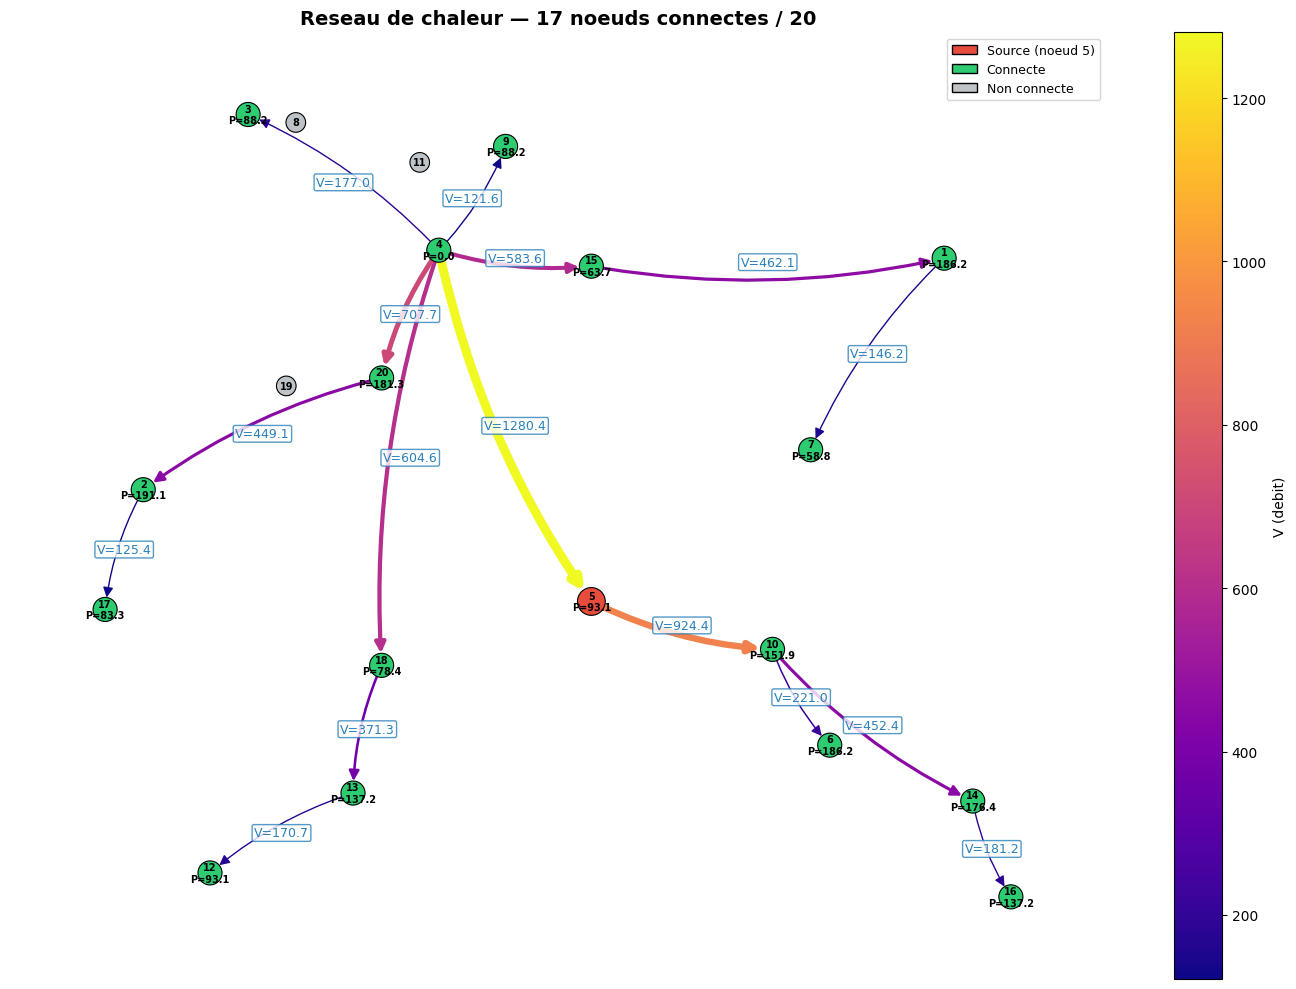


[Sauvegarde dans reseau_chaleur.png]


In [5]:
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import ast

# read the solution directly from solution.txt (no copy/paste)
with open("solution.txt", "r", encoding="utf-8") as sol:
    content = sol.read()

sections = content.split("\n\n")
built = {}
incoming_heat = {}
outcoming_heat = {}

for section in sections:
    section = section.strip()
    if section.startswith("built"):
        built = ast.literal_eval(section.split(" = ", 1)[1])
    elif section.startswith("incoming_heat"):
        incoming_heat = ast.literal_eval(section.split(" = ", 1)[1])
    elif section.startswith("outcoming_heat"):
        outcoming_heat = ast.literal_eval(section.split(" = ", 1)[1])

#  read the GPS coordinates from the Excel file
def read_excel_data(filename, sheet_name):
    data = pd.read_excel(filename, sheet_name=sheet_name, header=None)
    values = data.values
    if min(values.shape) == 1:
        if values.shape[0] == 1:
            values = values.tolist()
        else:
            values = values.transpose()
            values = values.tolist()
        return values[0]
    else:
        data_dict = {}
        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                data_dict[(i, j)] = values[i][j]
        return data_dict

f = INPUT_FILE
number_of_nodes = read_excel_data(f, "Nodes")[0]
cords = read_excel_data(f, "NodesCord")
D = read_excel_data(f, "EdgesDemandPeak(i)")
betta = read_excel_data(f, "Betta")[0]
lambda_ = read_excel_data(f, "Lambda")[0]
source_number = read_excel_data(f, "SourceNum")[0]

# Compute P (net power at each node) and V (flow on each pipe)
P = {}
for j in range(number_of_nodes):
    P[j] = 0.0
    for i in range(number_of_nodes):
        if i != j and built.get(i, {}).get(j, 0) == 1:
            P[j] += D[j] * betta * lambda_

V = {}
for i in range(number_of_nodes):
    V[i] = {}
    for j in range(number_of_nodes):
        V[i][j] = incoming_heat.get(i, {}).get(j, 0.0)

# Build the graph
g = nx.DiGraph()

# Add ALL nodes (including the unconnected ones)
for i in range(number_of_nodes):
    g.add_node(i)

# add the built pipes (i != j only)
edges_built = []
for i in range(number_of_nodes):
    for j in range(number_of_nodes):
        if i != j and built.get(i, {}).get(j, 0) == 1:
            g.add_edge(i, j)
            edges_built.append((i, j))

connected_nodes = set()
for (i, j) in edges_built:
    connected_nodes.add(i)
    connected_nodes.add(j)

#  Positions = GPS coordinates from the Excel file
pos = {}
for i in range(number_of_nodes):
    pos[i] = (cords[(i, 0)], cords[(i, 1)])

#  Labels en numerotation Excel (1 a 20)
labels = {}
for i in range(number_of_nodes):
    excel_num = i + 1
    if i in connected_nodes or i == source_number:
        labels[i] = f"{excel_num}\nP={P[i]:.1f}"
    else:
        labels[i] = f"{excel_num}"

# Node colors and sizes
node_colors = []
node_sizes = []
for n in g.nodes():
    if n == source_number:
        node_colors.append('#e74c3c')   # red = source
        node_sizes.append(400)
    elif n in connected_nodes:
        node_colors.append('#2ecc71')   # green = connected
        node_sizes.append(300)
    else:
        node_colors.append('#bdc3c7')   # grey = not connected
        node_sizes.append(200)

# Pipe colors and widths (proportional to V)
edge_widths = []
edge_colors = []
for (u, v) in edges_built:
    v_val = V[u][v]
    edge_widths.append(max(1.0, 0.005 * v_val))
    edge_colors.append(v_val)

cmap = plt.cm.plasma

# Drawing
plt.figure(figsize=(14, 10))

# Nodes
nx.draw_networkx_nodes(
    g, pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors='black',
    linewidths=0.8
)

# Labels
nx.draw_networkx_labels(g, pos, labels=labels, font_size=7, font_weight='bold')

# Pipes with V
if edges_built:
    edges_drawn = nx.draw_networkx_edges(
        g, pos,
        edgelist=edges_built,
        arrowstyle="-|>",
        arrowsize=15,
        edge_color=edge_colors,
        edge_cmap=cmap,
        width=edge_widths,
        connectionstyle='arc3,rad=0.1',
    )

    # Show V in the middle of each pipe
    for (u, v) in edges_built:
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        v_val = V[u][v]
        if v_val > 0:
            plt.text(mx, my, f"V={v_val:.1f}", fontsize=9, color='#2980b9',
                     ha='center', va='center',
                     bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                               edgecolor='#2980b9', alpha=0.8))

    # Colorbar
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=min(edge_colors), vmax=max(edge_colors))
    )
    sm.set_array([])
    plt.colorbar(sm, ax=plt.gca(), label="V (flow)")

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#e74c3c', edgecolor='black',
                   label=f'Source (node {source_number + 1})'),
    mpatches.Patch(facecolor='#2ecc71', edgecolor='black', label='Connected'),
    mpatches.Patch(facecolor='#bdc3c7', edgecolor='black', label='Not connected'),
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=9)

ax = plt.gca()
ax.set_axis_off()
plt.title(f"Heat network — {len(connected_nodes)} / {number_of_nodes} nodes connected",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("phase1_heat_network.png", dpi=150)
plt.show()
print("\n[Saved to phase1_heat_network.png]")
